### This notebook is for the purpose of EDA, in this notebook we have cleaned our data by handling null values,removing outliers, and visulaizing some important characterstic of data

In [647]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mlp


In [648]:
# Define a custom style with black background (matches presentation background)
grey_background_style = {
    'axes.facecolor': '#000000',  
    'figure.facecolor': '#000000',  
    'axes.edgecolor': 'white',  
    'axes.labelcolor': 'white',  
    'xtick.color': 'white',  
    'ytick.color': 'white',  
    'text.color': 'white',  
    'legend.facecolor': '#262626',  
    'legend.edgecolor': 'white'  
}

# Apply the custom style
plt.style.use(grey_background_style)

#### Read the data

In [649]:
df = pd.read_csv('data.csv')
df.head()

,data_year,victim_id,offender_id,relationship_id,nibrs_victim_offender_id,relationship_name,incident_id,victim_type_name,victim_age,victim_race,...,incident_hour,month_num,num_arestee,arrest_type_name,arrestee_weapon_name,state_name,region_name,county_name,latitude,longitude
0,2022,177976767,182684563,1,NaN,Victim Was Acquaintance,160891559.0,Individual,65 Years Old,White,...,19.0,8,1.0,On View,Unarmed,New Jersey,Northeast,ATLANTIC,-74.6869,39.5333
1,2022,179957439,184638493,26,NaN,Victim was Ex-Spouse,162620859.0,Individual,55 Years Old,Black or African American,...,9.0,8,NaN,NaN,NaN,New Jersey,Northeast,ATLANTIC,-74.6869,39.5333
2,2022,177976772,182684568,13,NaN,Victim Was In-law,160891564.0,Individual,52 Years Old,White,...,14.0,8,NaN,NaN,NaN,New Jersey,Northeast,ATLANTIC,-74.6869,39.5333
3,2022,179957440,184638494,3,NaN,Victim Was Boyfriend/Girlfriend,162620860.0,Individual,34 Years Old,White,...,23.0,8,1.0,On View,Unarmed,New Jersey,Northeast,ATLANTIC,-74.6869,39.5333
4,2022,177976775,182684571,1,NaN,Victim Was Acquaintance,160891567.0,Individual,27 Years Old,Black or African American,...,10.0,8,NaN,NaN,NaN,New Jersey,Northeast,ATLANTIC,-74.6869,39.5333


In [650]:
print("Dataframe shape",df.shape)
df.columns

Dataframe shape (47780, 52)


Index(['data_year', 'victim_id', 'offender_id', 'relationship_id',
       'nibrs_victim_offender_id', 'relationship_name', 'incident_id',
       'victim_type_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'property_id', 'property_value',
       'prop_desc_name', 'prop_loss_name', 'prop_loss_desc', 'est_drug_qty',
       'suspected_drug_name', 'drug_measure_name', 'offense_id',
       'attempt_complete_flag', 'location_name', 'offense_name',
       'crime_against', 'ct_flag', 'hc_flag', 'offense_category_name',
       'offense_group', 'bias_category_agg', 'bias_desc_agg',
       'multiple_biases', 'suspect_using_name', 'weapon_name', 'weapon_name.1',
       'multiple_weapons', 'incident_date', 'submission_date', 'incident_hour',
       'month_num', 'num_arestee', 'arrest_type_name', 'arrestee_weapon_name',
       'state_name', 'region_name', 'county_name', 'latitude', 'longitude']

Get id columns and drop them

In [651]:
get_id_columns = [column for column in df.columns if 'id' in column]
get_id_columns

['victim_id',
 'offender_id',
 'relationship_id',
 'nibrs_victim_offender_id',
 'incident_id',
 'property_id',
 'offense_id',
 'incident_date',
 'incident_hour']

In [652]:
# Since Incident contains id we retain them
df.drop(get_id_columns[:-2],axis=1,inplace=True)

#### Calulate null values

In [653]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_df = pd.DataFrame({'null_values':null_counts[null_counts>1],
             'Percentage':round(null_counts[null_counts>1]/df.shape[0],3)},index=None)
null_df.style.background_gradient(cmap='YlGnBu')


,null_values,Percentage
drug_measure_name,47780,1.000000
suspected_drug_name,47780,1.000000
est_drug_qty,47780,1.000000
property_value,33018,0.691000
prop_desc_name,33018,0.691000
arrestee_weapon_name,31372,0.657000
arrest_type_name,31372,0.657000
num_arestee,31372,0.657000
prop_loss_name,31245,0.654000
prop_loss_desc,31245,0.654000


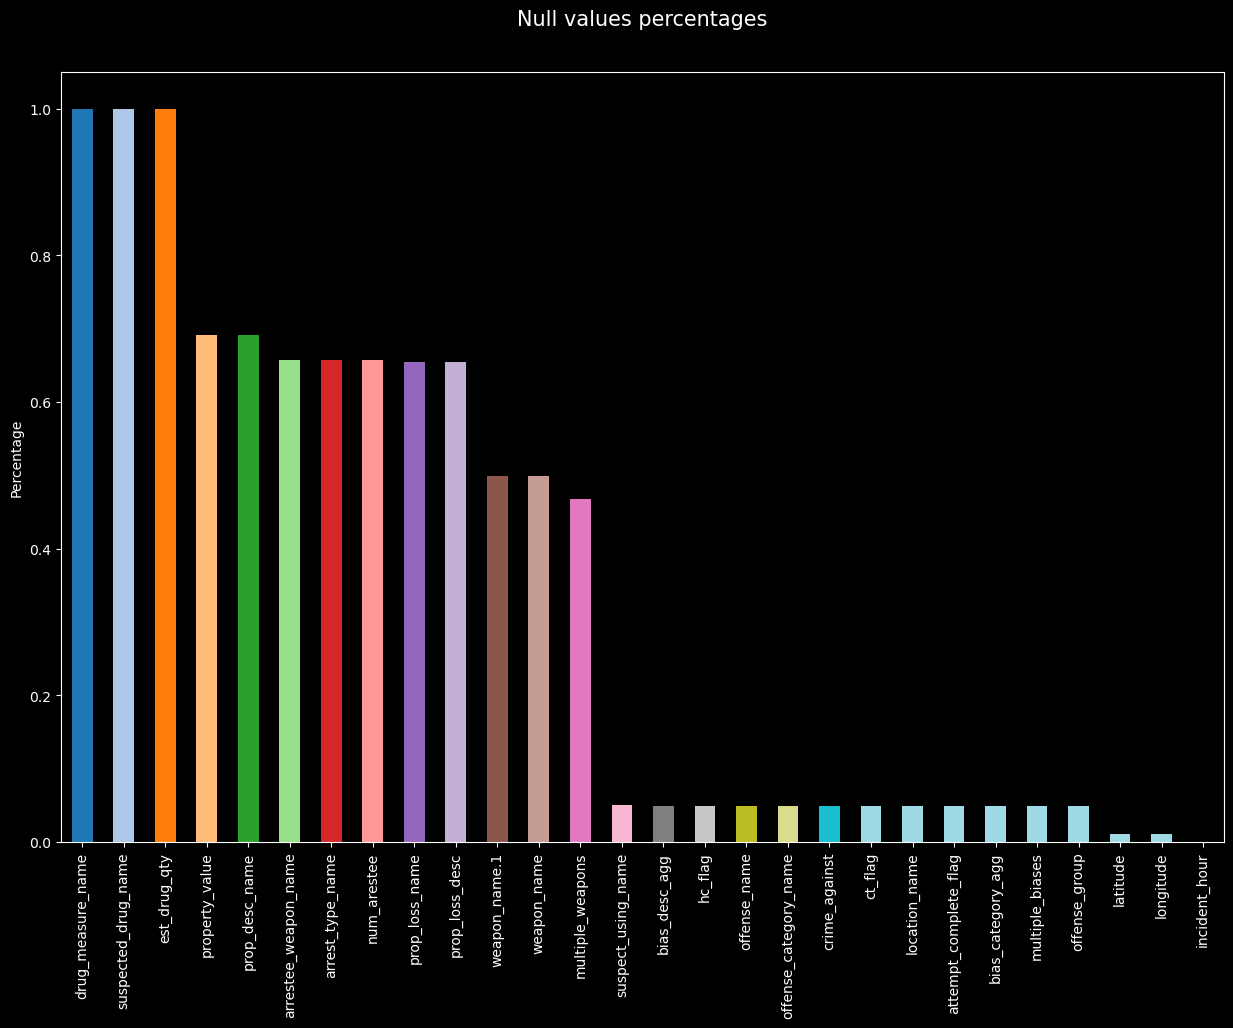

In [654]:
colors = plt.get_cmap('tab20')(np.linspace(0, 1, len(null_df)))

# Plotting the horizontal bar plot with manually set colors
ax = null_df['Percentage'].plot(kind='bar', figsize=(15, 10),color=[plt.get_cmap('tab20')(i) for i in range(len(null_df))])
ax.set_ylabel('Percentage')
ax.set_title("Null values percentages",color='white',fontsize=15,y=1.05)

# Show the plot
plt.show()

#### This function is for the purpose of imputing the null values for numerical features

In [655]:
def impute_numericals(df,approach="Drop"):

    numerical_df = df.select_dtypes(include=[np.number])

    #drop approach
    if approach == 'Drop':
        numerical_df = numerical_df.dropna(axis=0)

    #share approach
    if approach == 'Share':
        for feature in numerical_df:

            null_counts = numerical_df[feature].isnull().sum()
            value_counts = numerical_df[feature].value_counts()


            if null_counts!=df.shape[0] and null_counts / len(value_counts) >= 1:
                non_null_values = numerical_df[feature].dropna().unique()

                # shuffle non-null values to share them among missing values
                np.random.shuffle(non_null_values)

                # identify the indexes of missing values
                null_indexes = numerical_df[numerical_df[feature].isna()].index

                # calculate the number of times non-null values should be shared
                ratio = int(null_counts / len(non_null_values)) + 1

                # create a repeating pattern of non-null values
                repeated_values = np.tile(non_null_values, ratio)[:null_counts]

                # assign the repeated values to missing value locations
                numerical_df.loc[null_indexes, feature] = repeated_values
    
    # weighted approach
    if approach == 'Weighted':
        for feature in numerical_df:
            null_counts = numerical_df[feature].isnull().sum()
            if null_counts > 0:
                non_null_values = numerical_df[feature].dropna()

                # create weights_dict dynamically using value_counts
                value_counts = non_null_values.value_counts(normalize=True)
                weights_dict = {feature: {str(value): weight * 100 for value, weight in value_counts.items()}}

                # normalize weights to ensure they sum to 100
                total_weight = sum(weights_dict[feature].values())
                weights_dict[feature] = {key: value / total_weight for key, value in weights_dict[feature].items()}

                # generate random indices with weighted probabilities
                selected_indices = np.random.choice(np.arange(len(value_counts)), null_counts, p=list(weights_dict[feature].values()))

                # assign the selected non-null values to missing value locations
                numerical_df.loc[numerical_df[feature].isna(), feature] = value_counts.index[selected_indices]


    #Knn impute
    if approach == 'KNN':
        
        from sklearn.neighbors import KNeighborsRegressor

        from sklearn.impute import KNNImputer

        columns = numerical_df.columns

        #use fit_transform  
        imputer = KNNImputer(n_neighbors=5)
        # inverse fit transrom 
        numerical_df = imputer.fit_transform(numerical_df)

        numerical_df = pd.DataFrame(numerical_df,columns=columns)

    return numerical_df

#### This function is for the purpose of imputing the null values for categorical features

In [656]:
def impute_categoricals(df,approach='Drop'):
    
    categorical_df = df.select_dtypes(include='object')

    if approach=='Drop':
        categorical_df = categorical_df.dropna(axis=0)

    if approach == 'Share':
        for feature in categorical_df:

            null_counts = categorical_df[feature].isnull().sum()
            value_counts = categorical_df[feature].value_counts()


            if null_counts!=df.shape[0] and null_counts / len(value_counts) >= 1:
                non_null_values = categorical_df[feature].dropna().unique()

                # shuffle non-null values to share them among missing values
                np.random.shuffle(non_null_values)

                # identify the indexes of missing values
                null_indexes = categorical_df[categorical_df[feature].isna()].index

                # calculate the number of times non-null values should be shared
                ratio = int(null_counts / len(non_null_values)) + 1

                # create a repeating pattern of non-null values
                repeated_values = np.tile(non_null_values, ratio)[:null_counts]

                # assign the repeated values to missing value locations
                categorical_df.loc[null_indexes, feature] = repeated_values

    if approach == 'Weighted':
        for feature in categorical_df:
            null_counts = categorical_df[feature].isnull().sum()
            if null_counts > 0:
                non_null_values = categorical_df[feature].dropna()

                # create weights_dict dynamically using value_counts
                value_counts = non_null_values.value_counts(normalize=True)
                weights_dict = {feature: {str(value): weight * 100 for value, weight in value_counts.items()}}

                # normalize weights to ensure they sum to 100
                total_weight = sum(weights_dict[feature].values())
                weights_dict[feature] = {key: value / total_weight for key, value in weights_dict[feature].items()}

                # generate random indices with weighted probabilities
                selected_indices = np.random.choice(np.arange(len(value_counts)), null_counts, p=list(weights_dict[feature].values()))

                # assign the selected non-null values to missing value locations
                categorical_df.loc[categorical_df[feature].isna(), feature] = value_counts.index[selected_indices]

    if approach == 'KNN':


        from sklearn.impute import KNNImputer
        from sklearn.preprocessing import LabelEncoder
        encoders = {}
        columns = categorical_df.columns


        # encode the categorical features into integers
        for col in categorical_df.columns:
            le = LabelEncoder()
            categorical_df.loc[:,col] = le.fit_transform(categorical_df[col])
            encoders[col] = le

        # use fit_transform to impute 
        imputer = KNNImputer(n_neighbors=5)
        categorical_df = imputer.fit_transform(categorical_df)

        categorical_df = pd.DataFrame(categorical_df,columns=columns)

        # use encoders again to convert these integers into categories
        for col in categorical_df.columns:
            encoder = encoders[col]
            categorical_df[col] = encoder.inverse_transform(categorical_df[col].astype('int64').values)


    return categorical_df
    

#### This function totally handles null values based on the approach we pass to the function, and we are dropping the first 15 columns in null_df as these have missing values as majority 

In [657]:
def handling_null_values(df,approach='Drop'):

    #drop the features which have null values as majority
    null_counts = df.isnull().sum().sort_values(ascending=False)

    #dropping the first 13 values
    drop_features = list(null_counts[:13].index)
    #drop these features as these values are same for all rows
    drop_features.extend(['data_year','state_name','region_name'])
    df = df.drop(columns=list(drop_features),axis=1)

    # print("df_shape",df.shape)

    # impute using mean for latitude and longitude
    # df['latitude'] = df['latitude'].fillna(df['latitude'].mean())
    # df['longitude'] = df['longitude'].fillna(df['longitude'].mean())

    # impute numerical feature null values
    numerical_df = impute_numericals(df,approach)
    # print("numerical_df_shape",numerical_df.shape)

    #impute categorica feature null values
    categorical_df = impute_categoricals(df,approach)
    # print('numerical_df_shape',categorical_df.shape)

    #concat both categorical and numerical dataframes to get final dataframe
    df = pd.concat([categorical_df,numerical_df],axis=1)
    df.dropna(axis=0,inplace=True)
    return df
    

#### Since we only have county information that gives same longitude and latitude, to make it more kind of a real world scenario, we will add some gaussian noise to them 

In [658]:
def add_noise(df,ax,perturbation_scale=0.05,approach='KNN'):

    import numpy as np

    # print(approach,df['county_name'].unique())

    df = handling_null_values(df,approach)
    
     #adjust this value accordinglly
    df['latitude'] = df['latitude'] + perturbation_scale * (np.random.randn(len(df)))
    df['longitude'] = df['longitude'] + perturbation_scale * (np.random.randn(len(df)))


    import matplotlib.pyplot as plt
    import numpy as np

    # get all counties to color plot
    unique_counties = df['county_name'].unique()
    # print(approach,unique_counties)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_counties)))

    # create a scatter plot for each county
    for i, county in enumerate(unique_counties):
        county_data = df[df['county_name'] == county]
        representative_point = county_data.sample(n=1)  
        ax.scatter(county_data['latitude'], county_data['longitude'], color=colors[i], alpha=0.5, s=10)
        ax.text(representative_point['latitude'].values[0], representative_point['longitude'].values[0], county, fontsize=10)
        ax.set_title(f'Approach: {approach}')
        ax.set_xlabel('latitude')
        ax.set_ylabel('longitude')
        
    return df


##### This is the plot for latitude vs longitude colored by county_name, I have used four approaches for imputation and plotted the data points

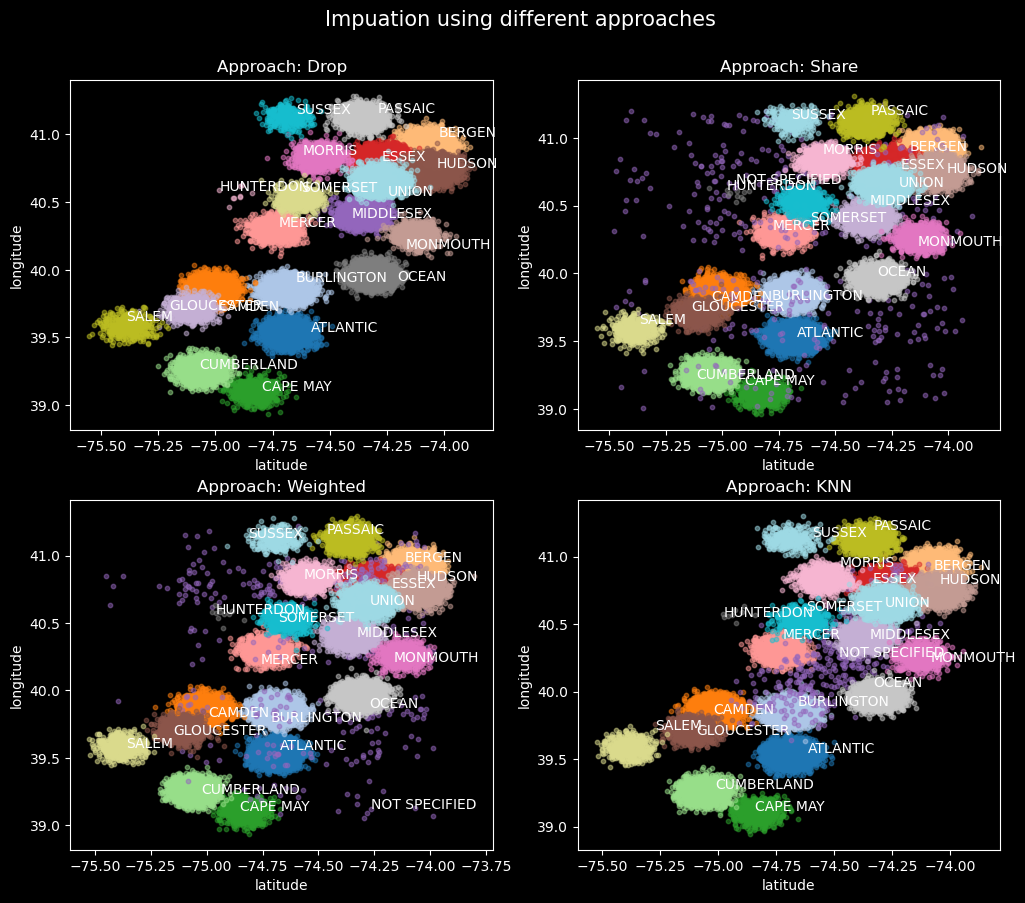

In [659]:
fig,axs = plt.subplots(2,2,figsize=(12,10))
plt.suptitle("Impuation using different approaches",y=0.95,fontsize=15)
axs = axs.ravel()

for approach,ax in zip(['Drop','Share','Weighted','KNN'],axs):
    add_noise(df.copy(),ax,approach=approach)

In [660]:
perturbation_scale = 0.05
df['latitude'] = df['latitude'] + perturbation_scale * (np.random.randn(len(df)))
df['longitude'] = df['longitude'] + perturbation_scale * (np.random.randn(len(df)))
df = handling_null_values(df,approach='Drop')

##### Convert Victim_age to numerical

In [661]:
# remove 'Unknown' values
df = df[df['victim_age'] != 'Unknown']

# extract numeric part from 'victim_age'
df ['victim_age']= df['victim_age'].str.extract('(\d+)').astype(float)

##### Convert Offender_age to numerical

In [662]:
# remove 'Unknown' values
df = df[df['offender_age'] != 'Unknown']

# extract numeric part from 'victim_age'
df['offender_age'] = df['offender_age'].str.extract('(\d+)').astype(float)

In [663]:
# statistics on the numerical data
df.describe()

,victim_age,offender_age,incident_hour,month_num,latitude,longitude
count,41967.000000,41967.000000,41967.000000,41967.000000,41967.000000,41967.000000
mean,37.417638,35.464055,11.755784,6.657040,-74.489138,40.304590
std,15.649614,13.829015,6.558140,3.279135,0.341512,0.574658
min,1.000000,1.000000,0.000000,1.000000,-75.545008,38.967941
25%,26.000000,25.000000,7.000000,4.000000,-74.717819,39.842945
50%,35.000000,34.000000,12.000000,7.000000,-74.355667,40.462621
75%,48.000000,44.000000,17.000000,9.000000,-74.243207,40.792416
max,98.000000,98.000000,23.000000,12.000000,-73.883966,41.299285


In [664]:
# gives non-null counts and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41967 entries, 0 to 47617
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   relationship_name      41967 non-null  object 
 1   victim_type_name       41967 non-null  object 
 2   victim_age             41967 non-null  float64
 3   victim_race            41967 non-null  object 
 4   victim_sex             41967 non-null  object 
 5   victim_ethnicity       41967 non-null  object 
 6   offender_age           41967 non-null  float64
 7   offender_sex           41967 non-null  object 
 8   offender_ethnicity     41967 non-null  object 
 9   offender_race          41967 non-null  object 
 10  attempt_complete_flag  41967 non-null  object 
 11  location_name          41967 non-null  object 
 12  offense_name           41967 non-null  object 
 13  crime_against          41967 non-null  object 
 14  ct_flag                41967 non-null  object 
 15  hc_flag

In [665]:
df.columns

Index(['relationship_name', 'victim_type_name', 'victim_age', 'victim_race',
       'victim_sex', 'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'attempt_complete_flag',
       'location_name', 'offense_name', 'crime_against', 'ct_flag', 'hc_flag',
       'offense_category_name', 'offense_group', 'bias_category_agg',
       'bias_desc_agg', 'multiple_biases', 'suspect_using_name',
       'incident_date', 'submission_date', 'county_name', 'incident_hour',
       'month_num', 'latitude', 'longitude'],
      dtype='object')

### EDA on numerical features

In [666]:
numerical_features = df.select_dtypes(include=np.number).columns

In [667]:
numerical_features

Index(['victim_age', 'offender_age', 'incident_hour', 'month_num', 'latitude',
       'longitude'],
      dtype='object')

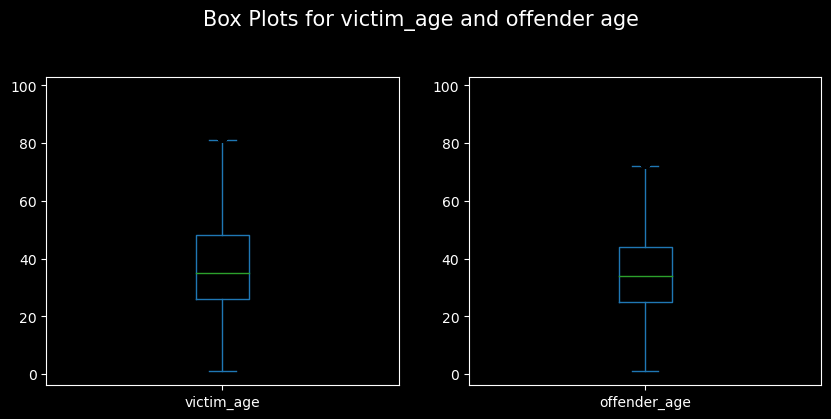

In [668]:
# plot the box plots
fig,axs = plt.subplots(1,2,figsize=(10,4))
axs = axs.ravel()
df['victim_age'].plot(kind='box',ax=axs[0],)
df['offender_age'].plot(kind='box',ax=axs[1])

plt.suptitle("Box Plots for victim_age and offender age", y=1.05,fontsize=15)
plt.show()

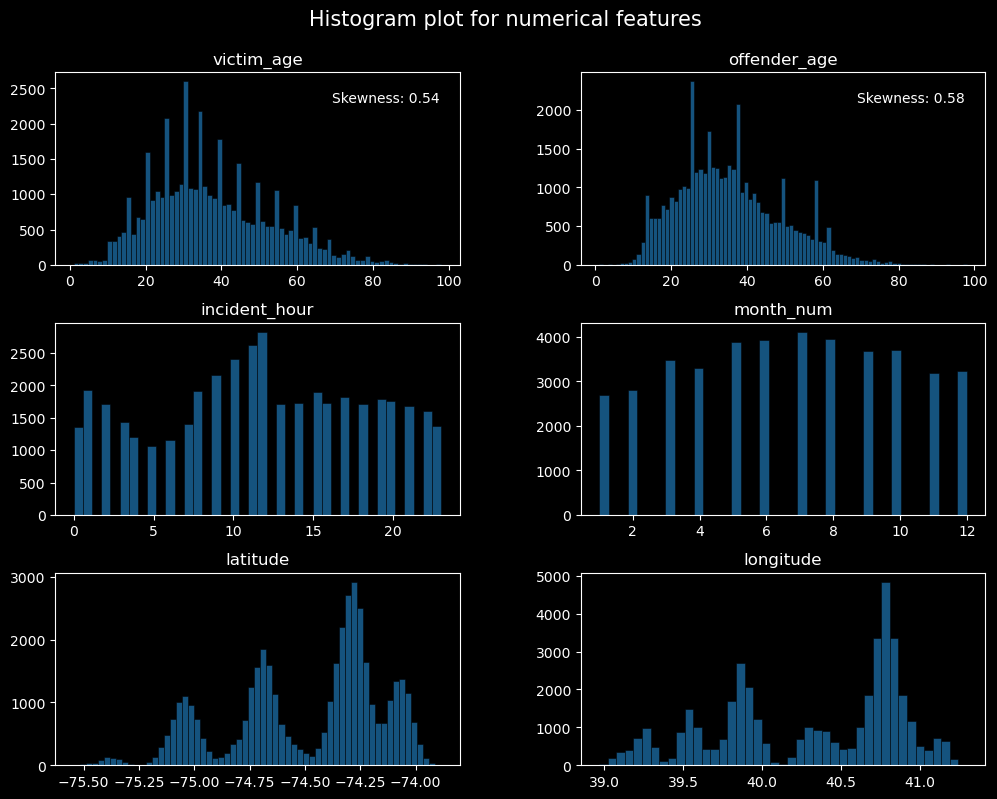

In [669]:
# plot the numerical features
axs = df[numerical_features].hist(bins='auto',figsize=(12,9),edgecolor='black',grid=False,alpha=0.7,linewidth=0.5)
axs[0][0].text(0.95, 0.9, f'Skewness: {df["victim_age"].skew():.2f}', transform=axs[0][0].transAxes, ha='right', va='top')
axs[0][1].text(0.95, 0.9, f'Skewness: {df["offender_age"].skew():.2f}', transform=axs[0][1].transAxes, ha='right', va='top')

plt.suptitle("Histogram plot for numerical features", y=0.95,fontsize=15)
plt.show()

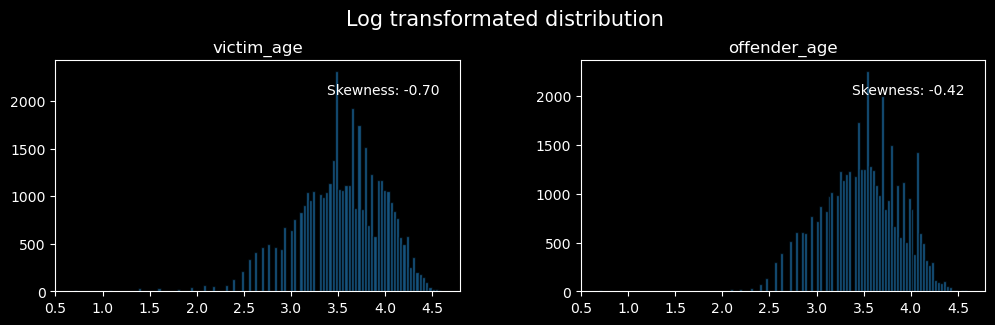

In [670]:
# plot the log transformed data for victim_age and offender_age
axs = np.log1p(df[numerical_features].iloc[:,:2]).hist(bins='auto',figsize=(12,3),edgecolor='black',grid=False,alpha=0.7,linewidth=1)
axs[0][0].text(0.95, 0.9, f'Skewness: {np.log1p(df["victim_age"]).skew():.2f}', transform=axs[0][0].transAxes, ha='right', va='top')
axs[0][1].text(0.95, 0.9, f'Skewness: {np.log1p(df["offender_age"]).skew():.2f}', transform=axs[0][1].transAxes, ha='right', va='top')

plt.suptitle("Log transformated distribution", y=1.05,fontsize=15)
plt.show()

##### As we can see now clearly that after log transformation of the data, we can seperate out outliers easily. We will drop those outliers which are 1% of total values

In [671]:
# log transform the victim_age and offender_age
df['victim_age'] = np.log1p(df['victim_age'])
df['offender_age'] = np.log1p(df['offender_age'])

In [672]:
df[df['victim_age'] < 2.5].shape[0] / df.shape[0]

0.016751256939976648

In [673]:
df = df[df['victim_age'] > 2.5]

In [674]:
df[df['offender_age'] < 2.7].shape[0] / df.shape[0]

0.017642497091896085

In [675]:
df = df[df['offender_age'] > 2.7]

In [676]:
df.shape

(40536, 29)

##### We can now clearly see the skewness in the data is reduced and more gaussian

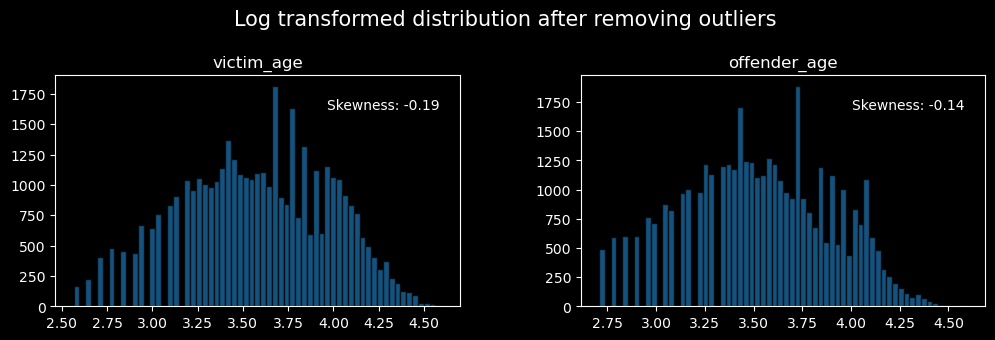

In [677]:
# plot the victim_age and offender_age after log transformation
axs = (df[numerical_features].iloc[:,:2]).hist(bins='auto',figsize=(12,3),edgecolor='black',grid=False,alpha=0.7,linewidth=1)
axs[0][0].text(0.95, 0.9, f'Skewness: {(df["victim_age"]).skew():.2f}', transform=axs[0][0].transAxes, ha='right', va='top')
axs[0][1].text(0.95, 0.9, f'Skewness: {(df["offender_age"]).skew():.2f}', transform=axs[0][1].transAxes, ha='right', va='top')

plt.suptitle("Log transformed distribution after removing outliers", y=1.1,fontsize=15)
plt.show()

### EDA on Cat features

In [678]:
cat_features = df.select_dtypes(include='object').columns
cat_features

Index(['relationship_name', 'victim_type_name', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_sex', 'offender_ethnicity',
       'offender_race', 'attempt_complete_flag', 'location_name',
       'offense_name', 'crime_against', 'ct_flag', 'hc_flag',
       'offense_category_name', 'offense_group', 'bias_category_agg',
       'bias_desc_agg', 'multiple_biases', 'suspect_using_name',
       'incident_date', 'submission_date', 'county_name'],
      dtype='object')

##### See whether we have value dominating the feature column

In [679]:
drop_cat_features = []
for feature in cat_features:
    vc = df[feature].value_counts().values
    if ((vc[0] / df.shape[0]) > 0.95) or (((vc[0] / df.shape[0]) > 0.9) and len(vc) >= 5):
    # if ((vc[0] / df.shape[0]) > 0.9):
        drop_cat_features.append(feature)

drop_cat_features

['victim_type_name',
 'attempt_complete_flag',
 'offense_group',
 'bias_category_agg',
 'bias_desc_agg',
 'multiple_biases']

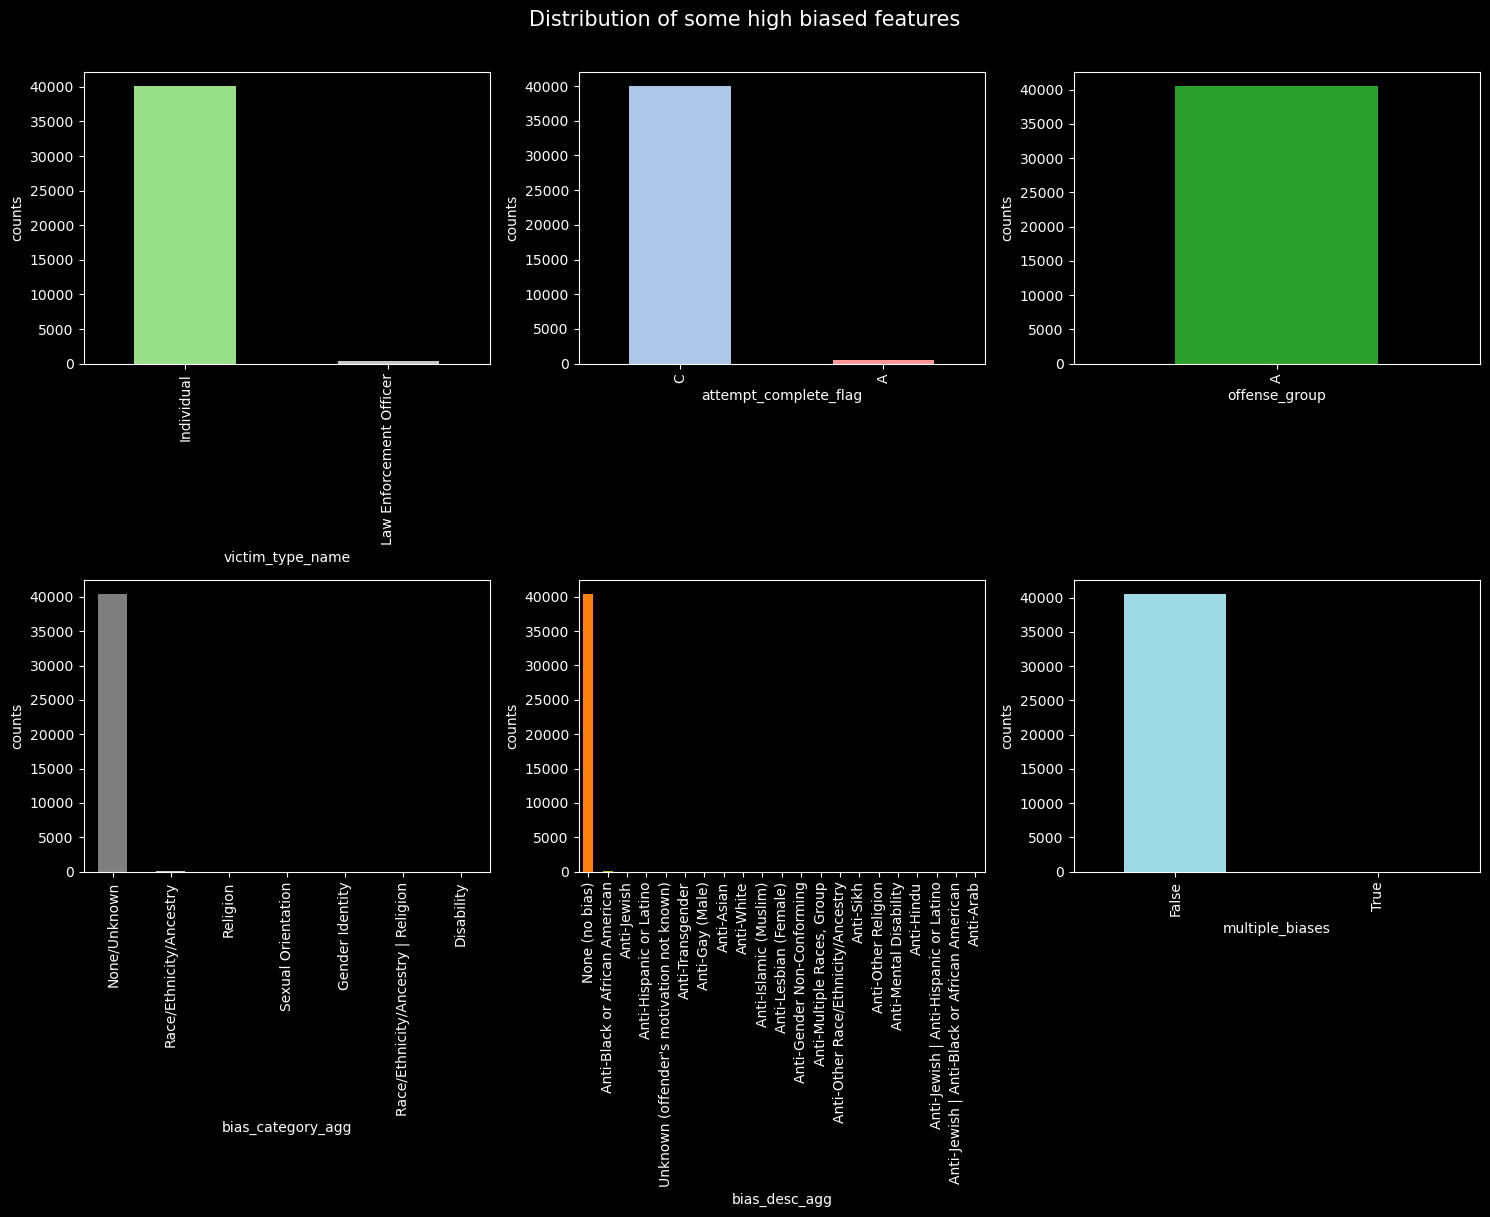

In [680]:
# plot these type of features
fig,axs = plt.subplots(2,3,figsize=(15,12))
axs = axs.ravel()
for feature,ax in zip(drop_cat_features,axs):
    df[feature].value_counts().\
        plot(kind='bar',color=[plt.get_cmap('tab20')(i) for i in np.random.rand(1,2).squeeze()],ax=ax).set_ylabel('counts')

plt.suptitle("Distribution of some high biased features",fontsize=15,y=1.01,color='white')
plt.tight_layout()
plt.show()

In [681]:
len(cat_features)

23

##### Ideal scenario would be to take these type of features into training set but for now I will drop these features

Dropping these because we have same values for all these

In [682]:
df.drop(['offense_group','attempt_complete_flag'],axis=1,inplace=True)
cat_features = df.select_dtypes(include='object').columns

In [683]:
df.drop(['victim_type_name',\
         'bias_category_agg','bias_desc_agg','multiple_biases'],axis=1,inplace=True)
cat_features = df.select_dtypes(include='object').columns

##### Plot the relationship b/w victim and offendder

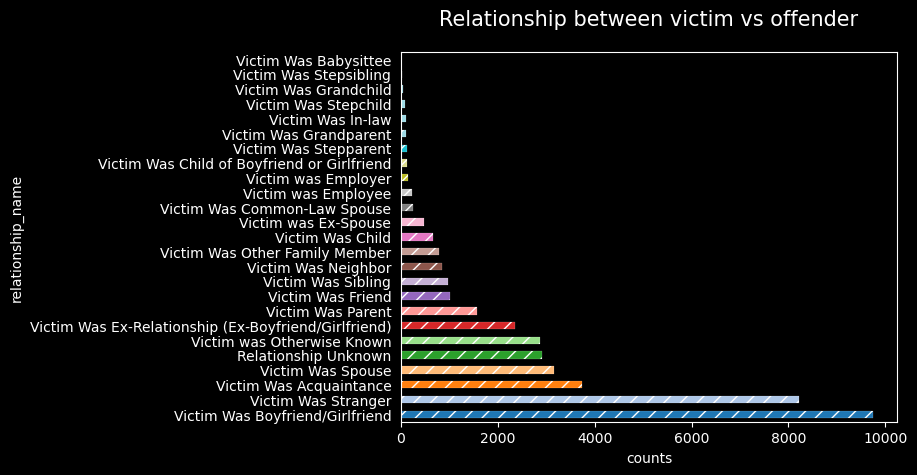

In [684]:
ax = df['relationship_name'].value_counts()\
    .plot(kind='barh',color=[plt.get_cmap('tab20')(i) for i in range(len(df['relationship_name']))],\
          hatch='//',edgecolor='white',linewidth=0.1)
ax.set_xlabel('counts')
ax.set_title("Relationship between victim vs offender",fontsize=15,color='white',y=1.05)
# ax.tick_params(axis='x',which='both',bottom=False)
ax.tick_params(axis='y',which='both',left=False)
# ax.set_yticks('off')

In [685]:
df.columns

Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'location_name', 'offense_name',
       'crime_against', 'ct_flag', 'hc_flag', 'offense_category_name',
       'suspect_using_name', 'incident_date', 'submission_date', 'county_name',
       'incident_hour', 'month_num', 'latitude', 'longitude'],
      dtype='object')

##### Plot the victim demographics

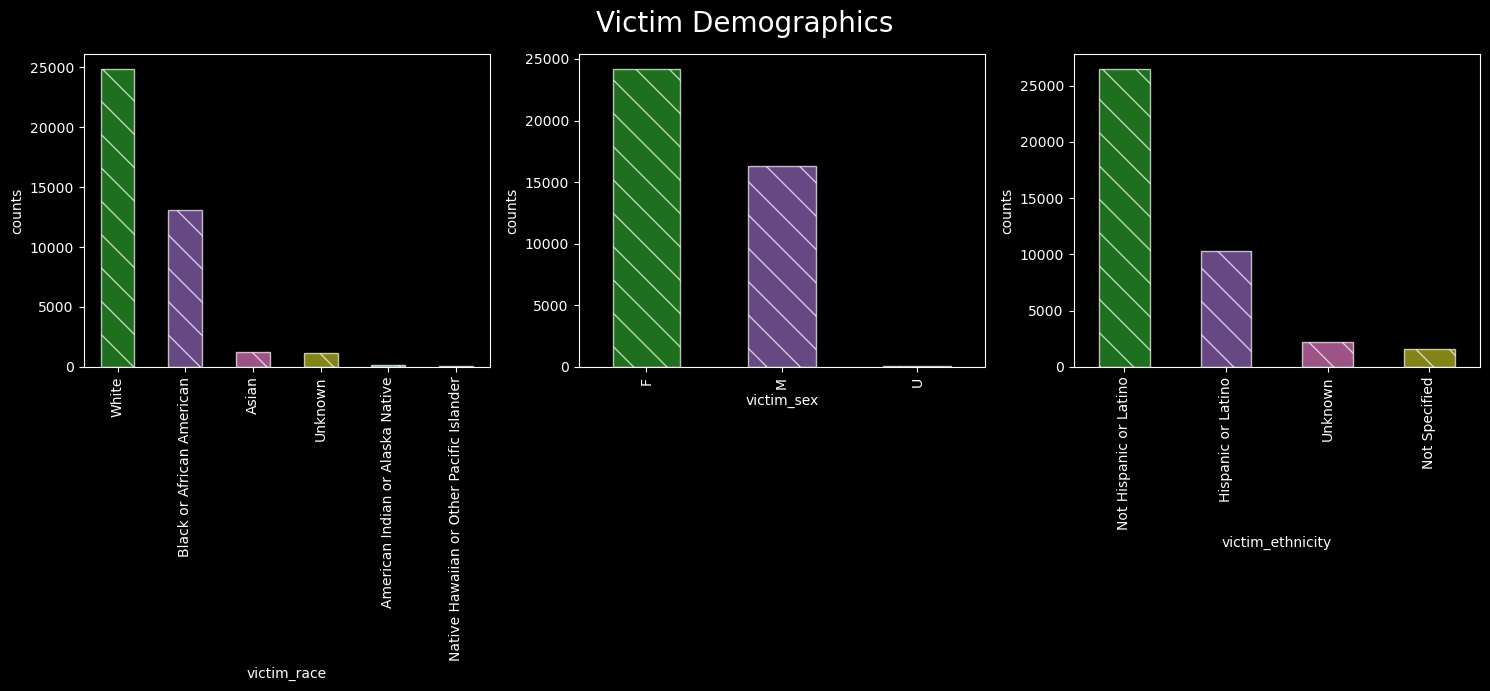

In [686]:

fig,axs = plt.subplots(1,3,figsize=(15,7))

fig.suptitle('Victim Demographics',fontsize=20,color='white')
axs = axs.ravel()
for feature,ax in zip(['victim_race','victim_sex','victim_ethnicity'],axs):
    df[feature].value_counts().plot(kind='bar',color=[plt.get_cmap('tab20')(i)for i in range(4,len(df[feature])+12,4)]\
              ,ax=ax,hatch='\\',edgecolor='white',alpha=0.7).set_ylabel('counts')
    ax.set_ylabel('counts')

plt.tight_layout()
plt.show()

In [687]:
df.columns

Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'location_name', 'offense_name',
       'crime_against', 'ct_flag', 'hc_flag', 'offense_category_name',
       'suspect_using_name', 'incident_date', 'submission_date', 'county_name',
       'incident_hour', 'month_num', 'latitude', 'longitude'],
      dtype='object')

##### Plot the offender demographics

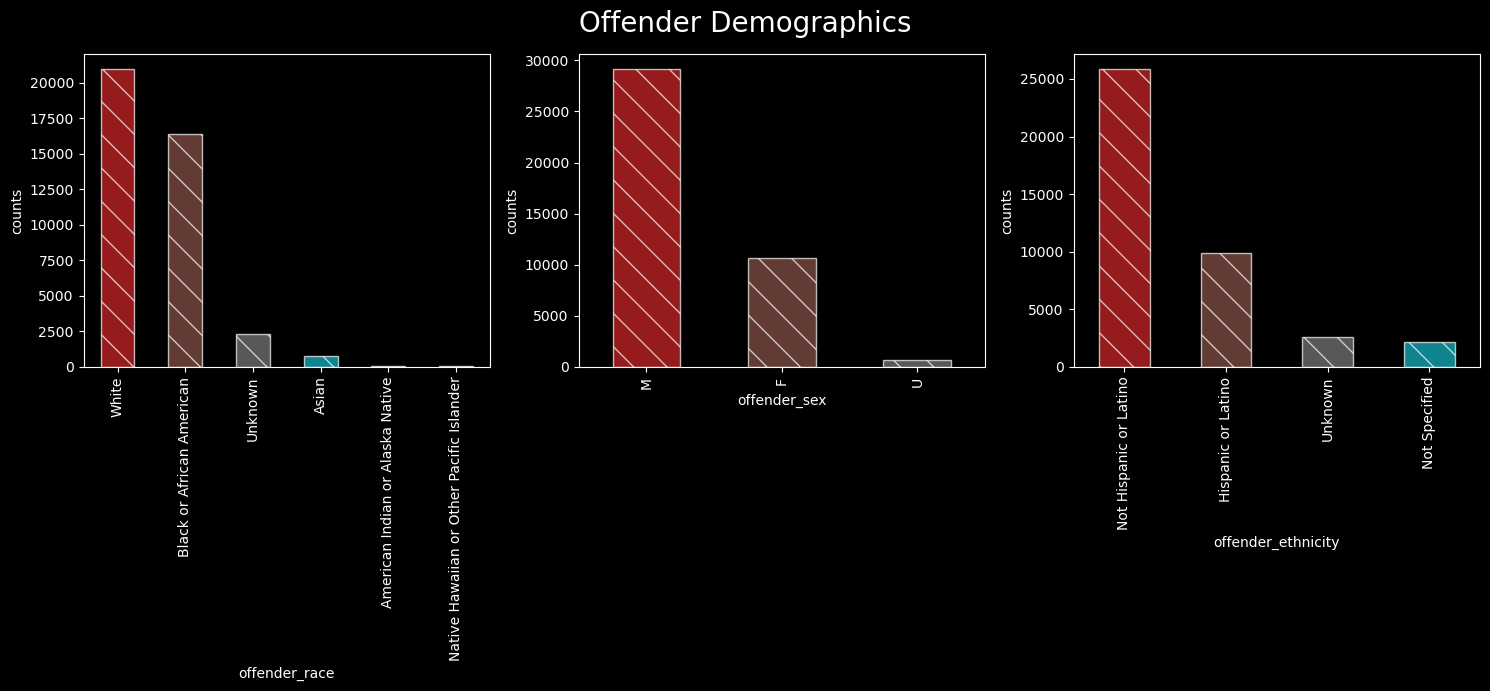

In [688]:

fig,axs = plt.subplots(1,3,figsize=(15,7))
fig.suptitle('Offender Demographics',fontsize=20,color='white')
axs = axs.ravel()
for feature,ax in zip(['offender_race','offender_sex','offender_ethnicity'],axs):
    counts = df[feature].value_counts()
    # counts\
    #     .plot(kind='bar',color=[plt.get_cmap('tab20')(i) for i in np.linspace(0.3,1, len(counts))]\
    #           ,ax=ax,hatch='/',edgecolor='white',alpha=0.7).set_ylabel('counts')

    df[feature].value_counts().plot(kind='bar',color=[plt.get_cmap('tab20')(i)for i in range(6,len(df[feature])+13,4)]\
            ,ax=ax,hatch='\\',edgecolor='white',alpha=0.7).set_ylabel('counts')
    

plt.tight_layout()
plt.show()

In [689]:
df.columns

Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'location_name', 'offense_name',
       'crime_against', 'ct_flag', 'hc_flag', 'offense_category_name',
       'suspect_using_name', 'incident_date', 'submission_date', 'county_name',
       'incident_hour', 'month_num', 'latitude', 'longitude'],
      dtype='object')

##### Plot the location where most incidents occur

Text(0.5, 0, 'counts')

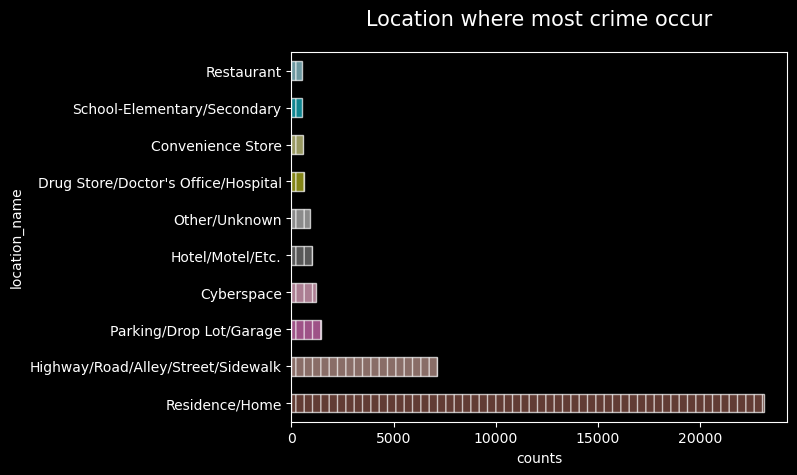

In [690]:
ax = df['location_name'].value_counts()[:10].plot(kind='barh',color=[plt.get_cmap('tab20')(i)for i in range(10,20)]\
            ,hatch='||',edgecolor='white',alpha=0.7)

ax.set_title('Location where most crime occur',y=1.05,fontsize=15,color='white')
ax.set_xlabel('counts')

##### Plot offenses

Text(0.5, 0, 'counts')

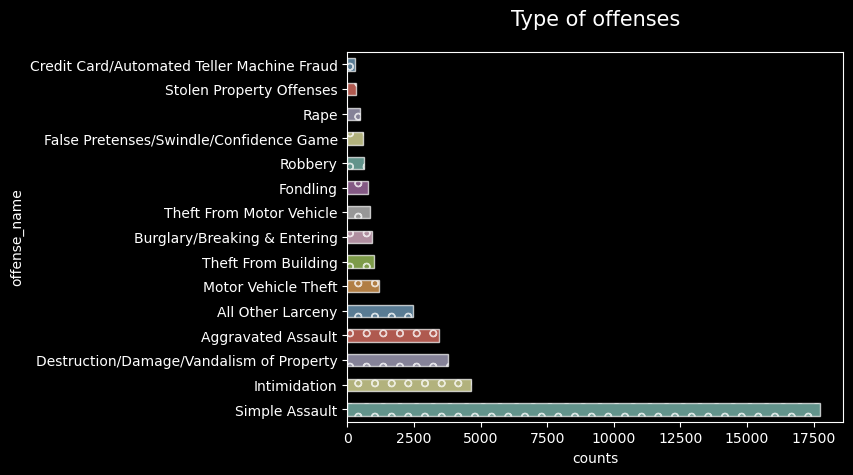

In [691]:
ax = df['offense_name'].value_counts()[:15].plot(kind='barh',color=[plt.get_cmap('Set3')(i)for i in range(0,10)]\
            ,hatch='o',edgecolor='white',alpha=0.7)

ax.set_title('Type of offenses',y=1.05,color='white',fontsize=15)
ax.set_xlabel('counts')

##### Plot offense categories

Text(0.5, 0, 'counts')

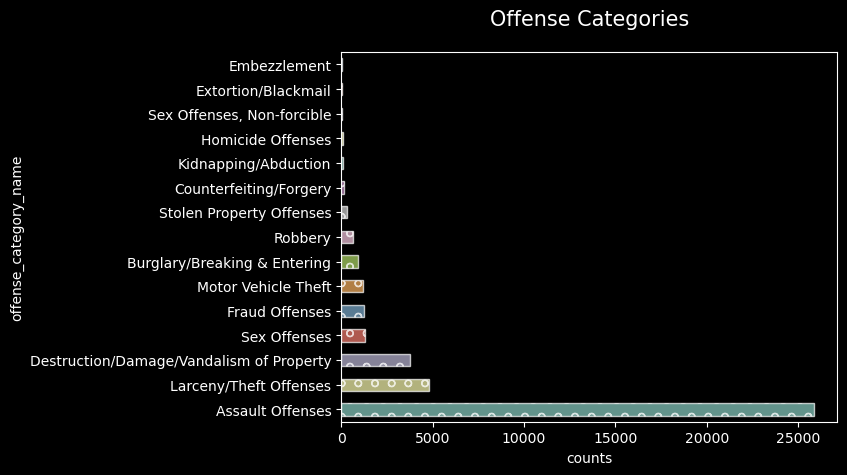

In [692]:
ax = df['offense_category_name'].value_counts()[:15].plot(kind='barh',color=[plt.get_cmap('Set3')(i)for i in range(0,10)]\
            ,hatch='o',edgecolor='white',alpha=0.7)

ax.set_title('Offense Categories',y=1.05,fontsize=15,color='white')
ax.set_xlabel('counts')

<Axes: ylabel='suspect_using_name'>

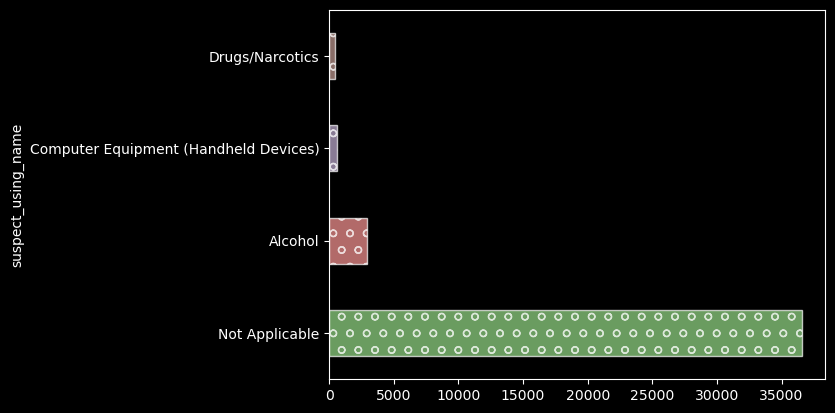

In [693]:
df['suspect_using_name'].value_counts().plot(kind='barh',color=[plt.get_cmap('tab20')(i)for i in range(5,20,2)]\
            ,hatch='o',edgecolor='white',alpha=0.7)


In [694]:
#since majority of them are not applicable we will drop this column
df.drop(['suspect_using_name'],axis=1,inplace=True)

##### Plot hate crime vs not hate crime 

Hate crime: A criminal act committed against a person, group, or property motivated by the perpetrator's bias against a particular race, religion, sexual orientation


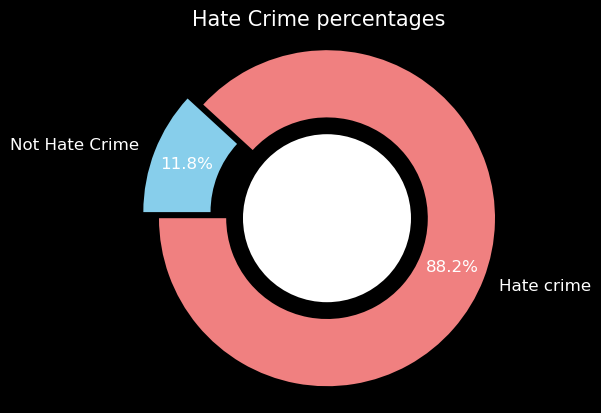

In [695]:
import matplotlib.pyplot as plt

sizes = df['hc_flag'].value_counts()
colors = ['lightcoral', 'skyblue']
explode = (0, 0.1)  # explode the 2nd slice

fig, ax = plt.subplots()
ax.pie(sizes, labels=['Hate crime','Not Hate Crime'], autopct='%1.1f%%', startangle=180, colors=colors,
        textprops=dict(color="w", size=12),wedgeprops=dict(width=0.4), explode=explode,pctdistance=0.8)

# add a circle at the center to create a donut chart
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
ax.add_patch(centre_circle)

plt.title('Hate Crime percentages', color='white', fontsize=15)

ax.axis('equal')

plt.show()


##### Plot person vs property crimes

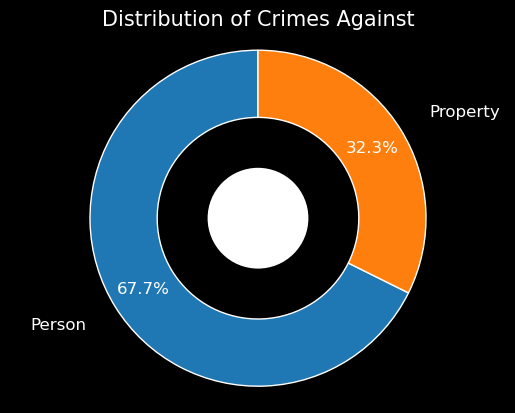

In [696]:
import matplotlib.pyplot as plt


crime_counts = df['crime_against'].value_counts()

# create a pie chart
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(crime_counts, labels=crime_counts.index, autopct='%1.1f%%', startangle=90,
                                   colors=plt.get_cmap('tab10').colors, wedgeprops=dict(width=0.4, edgecolor='w'),
                                   textprops=dict(color="w", size=12), labeldistance=1.2,pctdistance=0.8)

# draw a circle in the center to make it look like a donut chart
centre_circle = plt.Circle((0, 0), 0.3, color='black', fc='white', linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Crimes Against', color='white', fontsize=15)

ax.axis('equal')

plt.show()


As we can see our target variable Crimes Against have imbalance  in classes so we can use either down sampling or upsampling the data to balance out the data

In [697]:
df.columns

Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'location_name', 'offense_name',
       'crime_against', 'ct_flag', 'hc_flag', 'offense_category_name',
       'incident_date', 'submission_date', 'county_name', 'incident_hour',
       'month_num', 'latitude', 'longitude'],
      dtype='object')

In [698]:
# dict(df['offense_category_name'].value_counts(normalize=True))

##### Finally convert the object dtypes into numerical using label encoder

In [699]:
from sklearn.preprocessing import LabelEncoder

# categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

label_encoders = {}

# encode categorical variables
for column in categorical_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    label_encoders[column] = label_encoder



##### These are highly correlatied variables lets visualize some of them

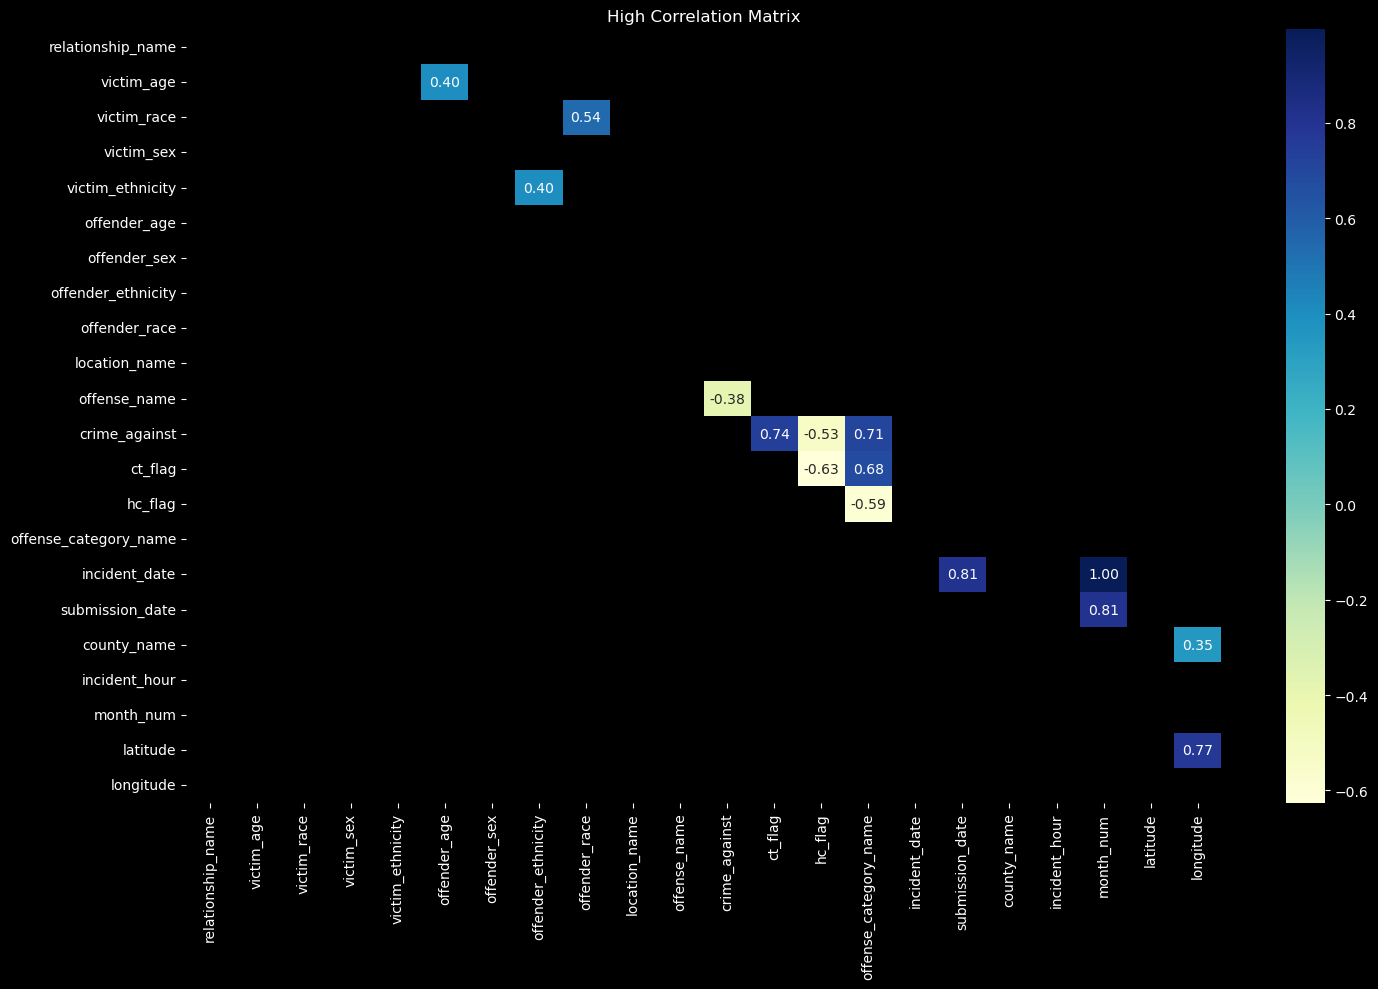

In [700]:
import seaborn as sns

corr_matrix = df.corr()

# get the upper triangle of the correlation matrix
upper_triangle = np.triu(corr_matrix, k=1)

# mask values below or equal to 0.3
mask = np.abs(upper_triangle) > 0.3

# Apply the mask to the correlation matrix
high_corr_matrix = corr_matrix.where(mask)

plt.figure(figsize=(15, 10))
sns.heatmap(high_corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('High Correlation Matrix')
plt.tight_layout()
plt.show()


- Dropping the incident_date and submission date as these are very scattered in distribution
- Removing the county name as we have feature engineered latitude and longitude

In [701]:
df.drop(['incident_date','submission_date','county_name'],axis=1,inplace=True)

He we can clearly observe how they are correlated, ex: assault offense is related to person rather than property, and destruction/theft offense is related to property

Text(0.5, 0, 'Counts')

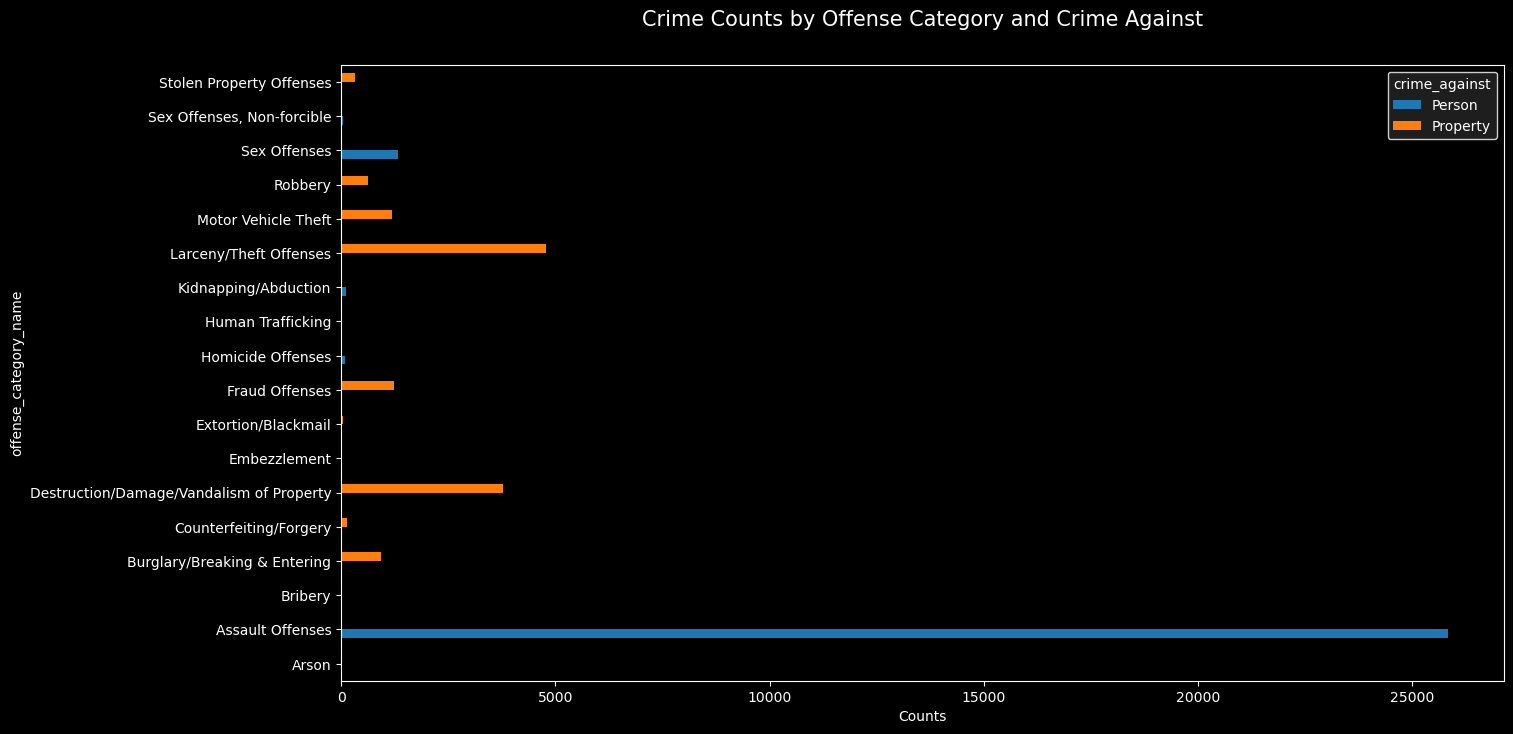

In [702]:
df_temp = df.copy()
feature_categories = label_encoders['offense_category_name'].inverse_transform(df['offense_category_name'])
crime_categories = label_encoders['crime_against'].inverse_transform(df['crime_against'])
df_temp['offense_category_name'] = feature_categories
df_temp['crime_against'] = crime_categories
ax = df_temp.groupby('offense_category_name')['crime_against'].value_counts().unstack().plot(kind='barh',figsize=(15,8))
ax.set_title('Crime Counts by Offense Category and Crime Against',fontsize=15,color='white',y=1.05)
ax.set_xlabel('Counts')


Isn't it interesing what kind of hate crime can result in crime against property

Text(0.5, 1.05, 'Crime Counts by Hate Crime and Crime Against')

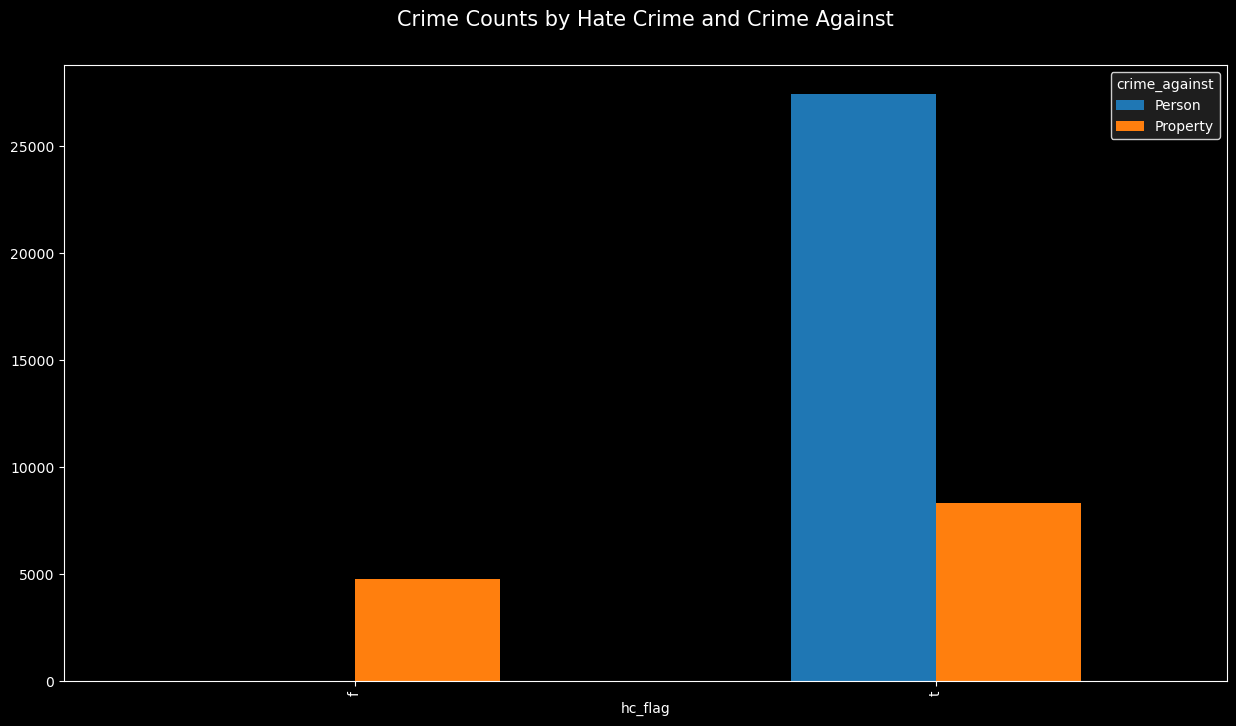

In [703]:
df_temp = df.copy()
feature_categories = label_encoders['hc_flag'].inverse_transform(df['hc_flag'])
crime_categories = label_encoders['crime_against'].inverse_transform(df['crime_against'])
df_temp['hc_flag'] = feature_categories
df_temp['crime_against'] = crime_categories
ax = df_temp.groupby('hc_flag')['crime_against'].value_counts().unstack().plot(kind='bar',figsize=(15,8))

ax.set_title('Crime Counts by Hate Crime and Crime Against',fontsize=15,color='white',y=1.05)


Text(0.5, 1.05, 'Crime Counts by Cargo Theft and Crime Against')

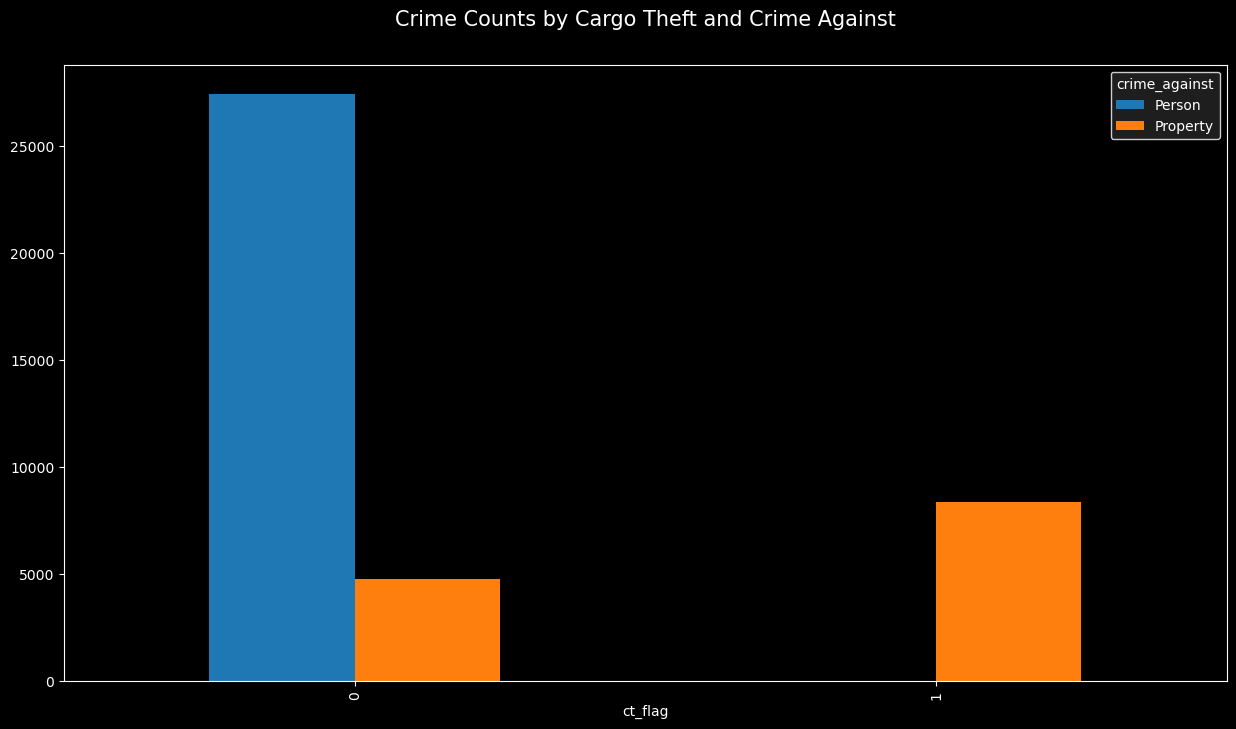

In [704]:
df_temp = df.copy()
feature_categories = label_encoders['ct_flag'].inverse_transform(df['ct_flag'])
crime_categories = label_encoders['crime_against'].inverse_transform(df['crime_against'])
df_temp['c_tflag'] = feature_categories
df_temp['crime_against'] = crime_categories
ax = df_temp.groupby('ct_flag')['crime_against'].value_counts().unstack().plot(kind='bar',figsize=(15,8))

ax.set_title('Crime Counts by Cargo Theft and Crime Against',fontsize=15,color='white',y=1.05)


In [705]:
print("Dataframe shape",df.shape),df.columns

Dataframe shape (40536, 19)


(None,
 Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
        'victim_ethnicity', 'offender_age', 'offender_sex',
        'offender_ethnicity', 'offender_race', 'location_name', 'offense_name',
        'crime_against', 'ct_flag', 'hc_flag', 'offense_category_name',
        'incident_hour', 'month_num', 'latitude', 'longitude'],
       dtype='object'))

In [706]:
df.to_csv('final_drop.csv',index=None)

#### Load the synthetic data generated using Mockaroo 

This dataset was prepared using AI generator from Mockaroo, the features are generated using weighted distribution according to their percentages in the original dataset. 

Link to website : https://www.mockaroo.com/

In [707]:
df_syn = pd.read_csv('synthetic_data.csv')
df_syn.head()

,victim_age,offender_age,incident_hour,latitude,longitude,month_num,relationship_name,victim_sex,offender_sex,victim_ethnicity,offender_ethnicity,victim_race,offender_race,location_name,offense_name,offense_category_name,crime_against,ct_flag,hc_flag
0,10,56,21,-74.06,39.74,4,Relationship Unknown,M,F,Not Hispanic or Latino,Not Hispanic or Latino,White,Black or African American,Highway/Road/Alley/Street/Sidewalk,Murder and Nonnegligent Manslaughter,Counterfeiting/Forgery,Property,True,True
1,32,33,4,-74.92,39.58,8,Victim Was Friend,F,F,Not Hispanic or Latino,Not Hispanic or Latino,White,Black or African American,Residence/Home,Identity Theft,Assault Offenses,Property,False,False
2,65,24,3,-74.73,39.78,6,Victim Was Sibling,F,F,Hispanic or Latino,Hispanic or Latino,Black or African American,Black or African American,Residence/Home,Simple Assault,Bribery,Property,False,True
3,93,100,12,-75.06,39.58,10,Victim Was Friend,F,F,Not Hispanic or Latino,Not Hispanic or Latino,White,White,Residence/Home,Intimidation,Sex Offenses,Property,True,True
4,17,56,2,-75.39,39.79,12,Victim Was Ex-Relationship (Ex-Boyfriend/Girlf...,F,F,Not Hispanic or Latino,Not Hispanic or Latino,White,White,Department/Discount Store,Impersonation,Counterfeiting/Forgery,Property,True,True


In [708]:
df_syn.isnull().sum().max()

0

In [709]:
df_syn.describe()

,victim_age,offender_age,incident_hour,latitude,longitude,month_num
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.394000,50.915000,11.385000,-74.702880,40.086020,6.502000
std,28.883092,29.424915,7.023112,0.485833,0.670951,3.386364
min,1.000000,1.000000,0.000000,-75.550000,38.960000,1.000000
25%,23.750000,24.000000,5.000000,-75.122500,39.520000,4.000000
50%,49.000000,52.500000,11.000000,-74.720000,40.050000,7.000000
75%,75.000000,76.000000,17.000000,-74.257500,40.670000,9.000000
max,100.000000,100.000000,23.000000,-73.900000,41.290000,12.000000


In [710]:
df_syn.columns

Index(['victim_age', 'offender_age', 'incident_hour', 'latitude', 'longitude',
       'month_num', 'relationship_name', 'victim_sex', 'offender_sex',
       'victim_ethnicity', 'offender_ethnicity', 'victim_race',
       'offender_race', 'location_name', 'offense_name',
       'offense_category_name', 'crime_against', 'ct_flag', 'hc_flag'],
      dtype='object')

convert the victim_age and offender_ge to log scale

In [711]:
df_syn['victim_age'] = np.log1p(df_syn['victim_age'])
df_syn['offender_age'] = np.log1p(df_syn['offender_age'])

The prepared dataset is clean now label encode it and use it for prediction

In [712]:
from sklearn.preprocessing import LabelEncoder

# categorical columns
categorical_columns = df_syn.select_dtypes(include=['object']).columns


# encode categorical variables
for column in categorical_columns:
    label_encoder = label_encoders[column]
    df_syn[column] = label_encoder.transform(df_syn[column])



In [713]:
df_syn.to_csv('synthetic_data_cleaned.csv',index=None)